In [ ]:
import pandas as pd
from pathlib import Path

csv_path = Path("..") / "part4" / "results" / "4_1" / "results.csv"
df = pd.read_csv(csv_path)
df.head()

,threads,cores,p95,qps,target,run
0,1,1,328.1,4892.5,5000,1
1,1,1,408.5,15029.5,15000,1
2,1,1,467.6,25073.0,25000,1
3,1,1,502.8,34775.0,35000,1
4,1,1,531.3,44878.0,45000,1


In [3]:
# Resolve column names case-insensitively and verify
cols_lower = {c.lower().strip(): c for c in df.columns}
threads_col = cols_lower.get("threads")
cores_col = cols_lower.get("cores")
target_col = cols_lower.get("target")
p95_col = cols_lower.get("p95")
qps_col = cols_lower.get("qps")
missing = [
    name for name, col in {
        "threads": threads_col,
        "cores": cores_col,
        "target": target_col,
        "p95": p95_col,
        "qps": qps_col,
    }.items() if col is None
]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available: {list(df.columns)}")

# Compute mean and std for p95 and qps grouped by threads, cores, and target
df_grouped_stats = (
    df.groupby([threads_col, cores_col, target_col], as_index=False)
      .agg(
          avg_p95=(p95_col, "mean"),
          std_p95=(p95_col, "std"),
          avg_qps=(qps_col, "mean"),
          std_qps=(qps_col, "std"),
      )
      .sort_values([threads_col, cores_col, target_col])
)

# Convert p95 stats from microseconds to milliseconds
df_grouped_stats[["avg_p95", "std_p95"]] = df_grouped_stats[["avg_p95", "std_p95"]] / 1000

df_grouped_stats.head()

,threads,cores,target,avg_p95,std_p95,avg_qps,std_qps
0,1,1,5000,0.332733,0.006295,4905.666667,20.678088
1,1,1,15000,0.402600,0.005260,14970.166667,51.386607
2,1,1,25000,0.459067,0.008652,24991.166667,118.321948
3,1,1,35000,0.499800,0.006538,34926.600000,155.111831
4,1,1,45000,0.534533,0.003855,44996.000000,107.857545


Averaged across 3 runs per target/configuration point.


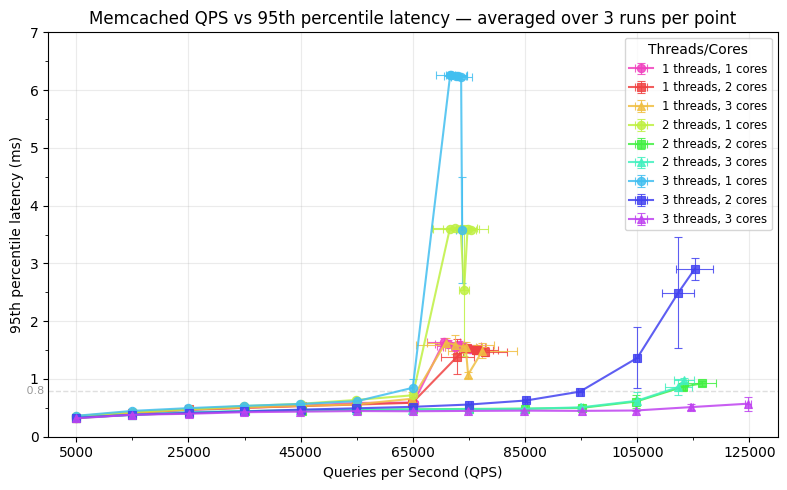

In [84]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import colorsys

n_runs = int(df['run'].nunique())

def get_marker(idx):
    markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*', 'h', '8']
    markers = ['o', 's', '^']
    return markers[idx % len(markers)]

def get_color(thread_idx, n_threads, core_idx, n_cores):
    base_hue = thread_idx / float(n_threads)
    hue_offset = (core_idx - (n_cores - 1) / 2) / max(n_cores, 2) * 0.36
    hue = (base_hue + hue_offset) % 1.0
    lightness = 0.6
    saturation = 0.85
    r, g, b = colorsys.hls_to_rgb(hue, lightness, saturation)
    return (r, g, b)

threads_list = sorted(df_grouped_stats[threads_col].unique())
cores_list = sorted(df_grouped_stats[cores_col].unique())
n_threads = len(threads_list)
n_cores = len(cores_list)

fig, ax = plt.subplots(figsize=(8, 5))

for t_idx, threads in enumerate(threads_list):
    sub_threads = df_grouped_stats[df_grouped_stats[threads_col] == threads]
    for c_idx, cores in enumerate(cores_list):
        sub = sub_threads[sub_threads[cores_col] == cores].sort_values('avg_qps')
        if sub.empty:
            continue
        color = get_color(t_idx, n_threads, c_idx, n_cores)
        marker = get_marker(c_idx)
        label = f"{threads} threads, {cores} cores"
        ax.errorbar(
            sub['avg_qps'],
            sub['avg_p95'],
            xerr=sub['std_qps'],
            yerr=sub['std_p95'],
            label=label,
            marker=marker,
            color=color,
            capsize=3,
            alpha=0.85,
            markersize=6,
            markeredgewidth=0.8,
            elinewidth=0.8
        )

ax.set_xlim(0, 130000)
ax.set_ylim(0, 7)
ax.set_xlabel('Queries per Second (QPS)')
ax.set_ylabel('95th percentile latency (ms)')
ax.set_title(f'Memcached QPS vs 95th percentile latency — averaged over 3 runs per point')
ax.set_xticks(range(5000, 130001, 20000))
ax.xaxis.set_minor_locator(plt.MultipleLocator(10000, 5000))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax.legend(title='Threads/Cores', loc='upper right', fontsize='small')
# Add custom grid line at y=0.8
ax.axhline(0.8, color='gray', linestyle='--', linewidth=1, alpha=0.25, zorder=0)
ax.grid(True, alpha=0.25)
ax.text(ax.get_xlim()[0] - 700, 0.8, ' 0.8', va='center', ha='right', color='gray', fontsize=8, alpha=0.8)
plt.tight_layout()
print(f'Averaged across 3 runs per target/configuration point.')

Averaged across 3 runs per target/configuration point.


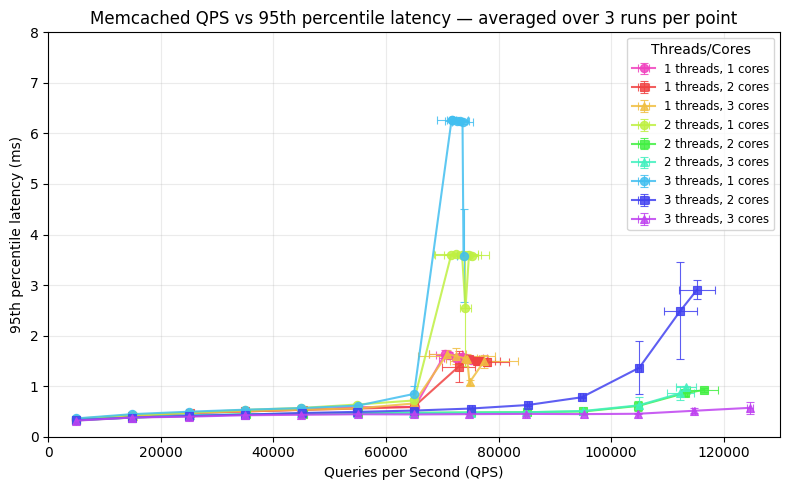

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import colorsys

def get_marker(idx):
    markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*', 'h', '8']
    markers = ['o', 's', '^']
    return markers[idx % len(markers)]

def get_color(thread_idx, n_threads, core_idx, n_cores):
    # Assign a base hue for each thread (distinct), then vary hue more for cores (similar but more distinct colors)
    base_hue = thread_idx / float(n_threads)
    # Increase hue spread for cores (±0.18 instead of ±0.09)
    hue_offset = (core_idx - (n_cores - 1) / 2) / max(n_cores, 2) * 0.36  # Spread hues ±0.18 around base_hue
    hue = (base_hue + hue_offset) % 1.0
    lightness = 0.6
    saturation = 0.85
    r, g, b = colorsys.hls_to_rgb(hue, lightness, saturation)
    return (r, g, b)

threads_list = sorted(df_grouped_stats[threads_col].unique())
cores_list = sorted(df_grouped_stats[cores_col].unique())
n_threads = len(threads_list)
n_cores = len(cores_list)

fig, ax = plt.subplots(figsize=(8, 5))

for t_idx, threads in enumerate(threads_list):
    sub_threads = df_grouped_stats[df_grouped_stats[threads_col] == threads]
    for c_idx, cores in enumerate(cores_list):
        sub = sub_threads[sub_threads[cores_col] == cores].sort_values('avg_qps')
        if sub.empty:
            continue
        color = get_color(t_idx, n_threads, c_idx, n_cores)
        marker = get_marker(c_idx)
        label = f"{threads} threads, {cores} cores"
        ax.errorbar(
            sub['avg_qps'],
            sub['avg_p95'],
            xerr=sub['std_qps'],
            yerr=sub['std_p95'],
            label=label,
            marker=marker,
            color=color,
            capsize=3,
            alpha=0.85,
            markersize=6,
            markeredgewidth=0.8,
            elinewidth=0.8
        )

ax.set_xlim(0, 130000)
ax.set_ylim(0, 8)
ax.set_xlabel('Queries per Second (QPS)')
ax.set_ylabel('95th percentile latency (ms)')
ax.set_title(f'Memcached QPS vs 95th percentile latency — averaged over 3 runs per point')
ax.legend(title='Threads/Cores', loc='upper right', fontsize='small')
ax.grid(True, alpha=0.25)
plt.tight_layout()
print(f'Averaged across 3 runs per target/configuration point.')